In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('..')
from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), 'analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [3]:
# pip install stepmix

In [4]:
myPredictorsDf = pd.read_csv('eICUPredictors.csv')

In [9]:
print(list(myPredictorsDf.columns))

['patientunitstayid', 'gender', 'age', 'apacheadmissiondx', 'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource', 'admissionweight', 'PEA', 'Asystole', 'VTachy', 'VFib', 'Hypothermia', 'FirstGCSTime', 'FirstGCS', 'LastGCSTime', 'LastGCS', 'FirstMGCSTime', 'FirstMGCS', 'LastMGCSTime', 'LastMGCS', 'Lactate', 'Troponin', 'pH', 'Chloride', 'hospitaldischargestatus', 'DeathAtDischarge', 'LastGCS15', 'GCS Total', 'Heart Rate', 'Non-Invasive BP Diastolic', 'Non-Invasive BP Mean', 'Non-Invasive BP Systolic', 'O2 Admin Device', 'O2 L/%', 'O2 Saturation', 'Respiratory Rate', 'Temperature (C)', 'Temperature (F)', 'Temperature Location', 'Value', 'Invasive BP Diastolic', 'Invasive BP Systolic', 'Pain Score', 'CI', 'PVR', 'Bedside Glucose', 'Eyes', 'Motor', 'Verbal', 'Invasive BP Mean', 'Delirium Scale', 'Delirium Score', 'Sedation Scale', 'Sedation Score', 'CPP', 'End Tidal CO2', 'ICP', 'CVP', 'CO', 'SVO2', 'SV', 'Pain Goal', 'Sedation Goal', 'Electrolyte Replacement', 'IAP', 'PR', 'QRS

In [17]:
myPredictorsDf.select_dtypes(include=['object']).columns

Index(['apacheadmissiondx', 'hospitaladmittime24', 'hospitaladmitsource',
       'FirstGCS', 'LastGCS', 'hospitaldischargestatus', 'GCS Total',
       'O2 Admin Device', 'Temperature Location', 'Value', 'Delirium Scale',
       'Delirium Score', 'Sedation Scale', 'Electrolyte Replacement',
       'Fall Risk'],
      dtype='object')

In [22]:
# myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int
myFilter = (myPredictorsDf['FirstGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstGCS'].isna()) & (myPredictorsDf['LastGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['FirstMGCS'].isna()) & (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime']) & (myPredictorsDf['FirstGCSTime'] != myPredictorsDf['LastGCSTime'])
myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
myPredictorsDf.LastGCS15 = 0
myPredictorsDf.loc[myFilter, 'LastGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastGCS'].astype(int) > 8).astype(int)
myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(int) == 6).astype(int)

In [23]:
myPredictorsDf.columns

Index(['patientunitstayid', 'gender', 'age', 'apacheadmissiondx',
       'admissionheight', 'hospitaladmittime24', 'hospitaladmitsource',
       'admissionweight', 'PEA', 'Asystole',
       ...
       'Pressure Control', 'Vent Other', 'WBC's in peritoneal fluid',
       'Cyclosporin', 'Site', 'Amikacin - peak', 'PTT ratio',
       'Vancomycin - peak', 'LastGCSPositive', 'LastMGCSPositive'],
      dtype='object', length=230)

In [33]:
myXValue = myPredictorsDf.drop(columns= ['Motor', 'LastMGCSPositive', 'LastMGCS', 'Sedation Scale', 'Electrolyte Replacement', 'Fall Risk', 'O2 Admin Device', 'Temperature Location', 'Value', 'Delirium Scale', 'Delirium Score', 'LastGCSPositive', 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
myXValue = myXValue[myFilter]
myXValue.FirstGCS = myXValue.FirstGCS.astype(int)
myYValue = myPredictorsDf[myFilter]['LastMGCSPositive']
myYValue = myYValue.astype(int)

X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[myFilter][['LastGCS15', 'Hypothermia']], test_size=0.40)

In [34]:
myGridSearchCv = gridSearchKFoldClassification(X_train=X_train, X_test = X_test, y_train = y_train, y_test=y_test, aScore='roc_auc')
myBestModel = myGridSearchCv.best_estimator_

/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: [155]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: [155]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: [155]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/home/idies/miniconda3/lib/python3.9/site-packages/sklearn/impute/_base.py:555: UserWarning: Skipping features without any observed values: [155]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/home/idies/miniconda3/lib/pytho

Best parameters: {'clf': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...), 'clf__max_depth': 10, 'clf__n_estimators': 50}
Best cross val roc_auc score: 0.8329
Area under the receiver operating curve on test set is 0.8366
Accuracy score on test set is 0.7435


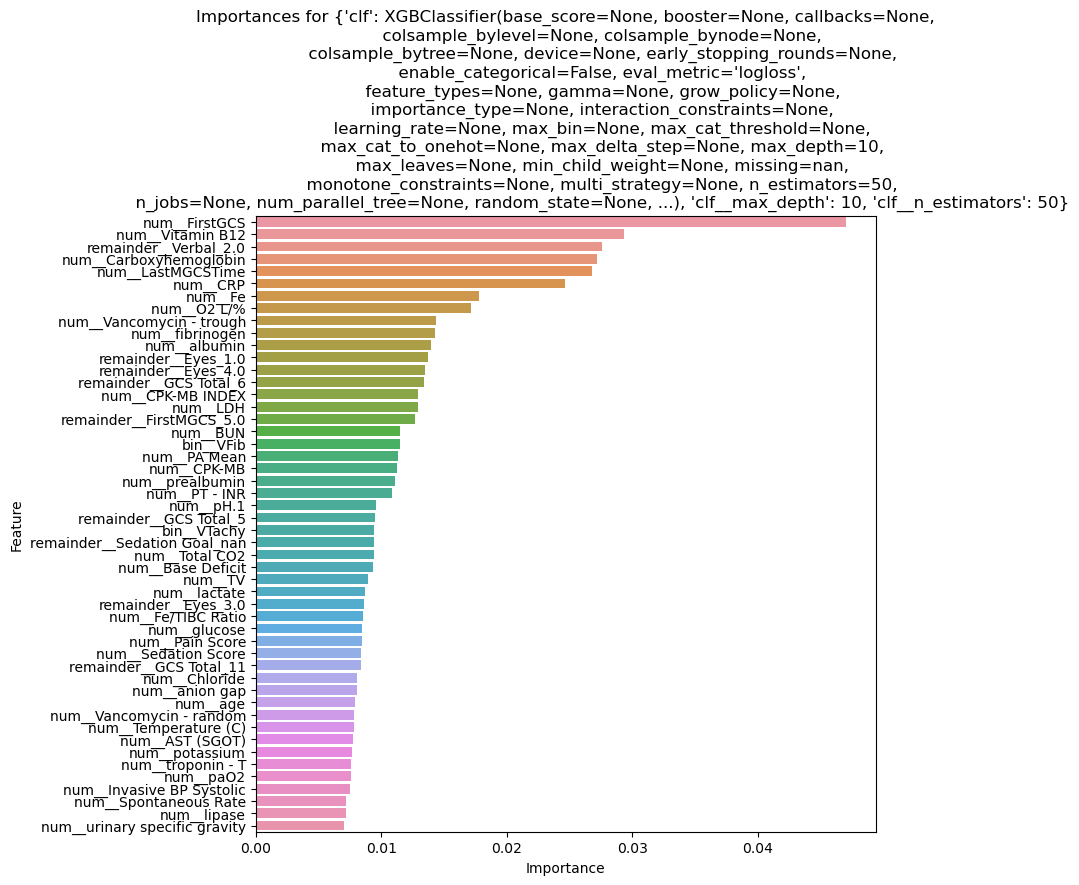

In [35]:
myFeatureImportancesDf = getTopFeatures(myGridSearchCv, list(myBestModel.named_steps.preprocessor.get_feature_names_out()), X_train, y_train)

In [38]:
def getTreatmentEffectDiff(X_train, y_train, aModel, aCategory = 'CPC12', aGroup = 'groupe'):
    lower_third, upper_third, myNewDf = getPredictedTreatmentEffectSupervisedClassif(X_train, aModel, aCategory, aGroup)
    print(lower_third)
    print(upper_third)
    if upper_third == lower_third:
        print(f'No effect difference')
        return 1
    myData = pd.concat([X_train[aGroup], myNewDf['predicted_effect_group'], y_train], axis=1)
    model1 = smf.logit(
        f'{aCategory} ~ predicted_effect_group + {aGroup}',
        data=myData
    ).fit()

    model2 = smf.logit(
        f'{aCategory} ~ predicted_effect_group * {aGroup}',
        data=myData
    ).fit()

    llr = -2*(model1.llf - model2.llf)
    df_diff = model2.df_model - model1.df_model
    p_value = chi2.sf(llr, df_diff)

    print(f'Likelihood ratio of test results:')
    print(f'Chi square statistic: {llr}')
    print(f'p-value: {p_value}')
    print(f'Degress of freedom: {df_diff}')
    print(f'NonInteraction p-value: {model1.summary()}')
    print(f'Interaction p-value: {model2.summary()}')
    return p_value

In [39]:
# getTreatmentEffectDiff(myXValue, myYValue, myBestModel, 'LastGCS15', 'Hypothermia')
# myNewDf = pd.DataFrame()
# myNewDf['predicted_effect_group'] = myBestModel.predict(X_test)
getTreatmentEffectDiff(X_test, y_test, myBestModel, 'LastMGCSPositive', 'Hypothermia')

TypeError: getPredictedTreatmentEffectSupervisedClassif() takes 3 positional arguments but 4 were given

0.008270536882598595
0.021325521400884166
Optimization terminated successfully.
         Current function value: 0.685453
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.682280
         Iterations 4
Likelihood ratio of test results:
Chi square statistic: 7.0431071161956424
p-value: 0.029553486426956876
Degress of freedom: 2.0
NonInteraction p-value:                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                 1110
Model:                          Logit   Df Residuals:                     1106
Method:                           MLE   Df Model:                            3
Date:                Sun, 29 Dec 2024   Pseudo R-squ.:                0.007189
Time:                        22:59:02   Log-Likelihood:                -760.85
converged:                       True   LL-Null:                       -766.36
Covariance Type:            nonrobust   LLR p-va

0.029553486426956876

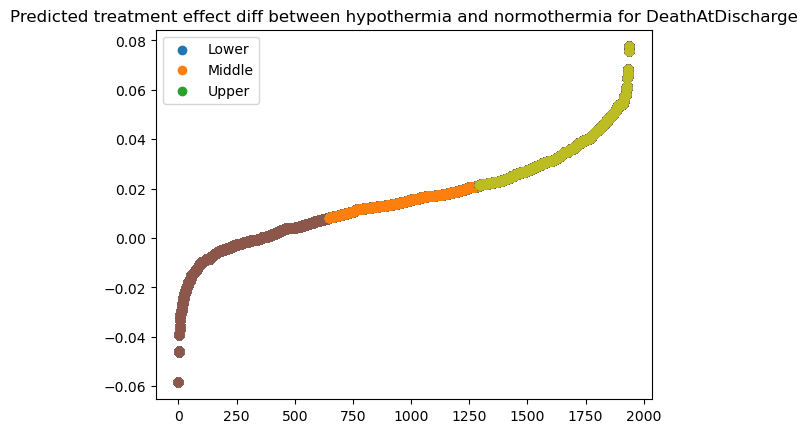

In [74]:
getTreatmentEffectDiff(X_train, y_train, myBestModel, 'DeathAtDischarge', 'Hypothermia')